## Parameters

In [79]:
EXP_RESULT_DIR = "../tmp/exps/"

In [80]:
# DEVICE_CONFIGS = ["0", "1", "2", "3"]
DEVICE_CONFIGS = ["0,1", "2,3"]

In [81]:
common_params = {
    "params.model.path": [
        # Small models
        "Qwen/Qwen2.5-1.5B-Instruct",
        "Qwen/Qwen2.5-7B-Instruct",
        "meta-llama/Llama-3.1-8B-Instruct",
        
        # Medium models
        "Qwen/Qwen2.5-14B-Instruct",
        "Qwen/Qwen2.5-32B-Instruct",
        "Qwen/Qwen2.5-Coder-32B-Instruct",
        # "Qwen/QwQ-32B",
        
        # GRPO models
        "bdsaglam/Qwen2.5-1.5B-Instruct-ragent-musique",
        "bdsaglam/Llama-3.1-8B-Instruct-ragent-grpo-musique-merged",
        # "/home/baris/repos/verifiers/outputs/Llama-3.1-8B-Instruct-ragent-2",
        # "/home/baris/repos/verifiers/outputs/Llama-3.1-8B-Instruct-ragent-20250421_000014-400",
        # "/home/baris/repos/verifiers/outputs/Llama-3.1-8B-Instruct-ragent-20250421_000014-1600",
        # "/home/baris/repos/verifiers/outputs/Llama-3.1-8B-Instruct-ragent-20250421_000014-1900",
    ],
    "params.model.temperature": [
        0.3,
        0.5,
        0.7,
    ],
    "params.model.top_p": [
        0.95,
    ],
    "params.model.few_shot_prob": [
        0.0,
        1.0,
    ],
    "params.retriever.name": [
        # "semantic",
        # "lexical",
        # "hybrid",
        "hybrid-tei",
    ],
    "params.retriever.top_k": [
        1,
        2,
        3,
    ],
    "params.retriever.mode": [
        # "new",
        "all",
    ],
    "params.run": [
        1,
        # 2,
        # 3
    ],
}

In [82]:
varying_params_list = [
    {
        "params.dataset.path": ["bdsaglam/musique-mini"],
        "params.dataset.name": ["answerable"],
        "params.dataset.split": ["validation"],
    },
    # {
    #     "params.dataset.path": ["bdsaglam/hotpotqa-distractor"],
    #     "params.dataset.name": ["default"],
    #     "params.dataset.split": ['validation[:300]'],
    # },
]

## Setup

In [83]:
# AUTOGENERATED! DO NOT EDIT! File to edit: ../../nbs/dvc.experiment.ipynb.

# %% auto 0
__all__ = ["parse_params", "parse_metrics", "parse_experiment", "parse_experiments", "load_experiments"]

# %% ../../nbs/dvc.experiment.ipynb 3
import json
from typing import Generator


# %% ../../nbs/dvc.experiment.ipynb 4
def parse_params(record):
    params_node = record.get("data", {}).get("params", {})
    params = {}
    for k, v in params_node.items():
        params.update(v.get("data", {}))
    return params


def parse_metrics(record):
    metrics_node = record.get("data", {}).get("metrics", {})
    metrics = {}
    for k, v in metrics_node.items():
        metrics.update(v.get("data", {}))
    return metrics


def parse_experiment(record):
    return {
        "id": record["rev"],
        "name": record["name"],
        "params": parse_params(record),
        "metrics": parse_metrics(record),
    }


def parse_experiments(data: list[dict]) -> Generator[dict, None, None]:
    for node in data:
        if node.get("error"):
            continue
        commit = node.get("rev")
        if experiments := (node.get("experiments") or []):
            for experiment in experiments:
                for rev in experiment.get("revs") or []:
                    if not rev.get("error"):
                        yield {"commit": commit, **parse_experiment(rev)}
        else:
            yield {"commit": commit, **parse_experiment(node)}


def load_experiments(json_filepath):
    with open(json_filepath, "r") as f:
        data = json.load(f)
    return list(parse_experiments(data))


In [84]:
import itertools
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn

In [85]:
def sorted_tuple(x):
    return tuple(sorted(x))

In [86]:
def jprint(obj):
    print(json.dumps(obj, indent=2))

In [87]:
filepaths = list(Path(EXP_RESULT_DIR).glob("*.json"))
experiments = [exp for fp in filepaths for exp in load_experiments(fp)]
for exp in experiments:
    if 'mode' not in exp['params']['retriever']:
        exp['params']['retriever']['mode'] = 'new'
print(f"{len(experiments)} experiments")
jprint(next(iter(experiments), None))

131 experiments
{
  "commit": "workspace",
  "id": "workspace",
  "name": null,
  "params": {
    "dataset": {
      "path": "bdsaglam/musique-mini",
      "name": "answerable",
      "split": "validation"
    },
    "model": {
      "path": "bdsaglam/Llama-3.1-8B-Instruct-ragent-grpo-musique-merged",
      "temperature": 0.5,
      "top_p": 0.95,
      "few_shot_prob": 0.0
    },
    "retriever": {
      "name": "hybrid-tei",
      "top_k": 1,
      "mode": "all"
    },
    "run": 1,
    "devices": "0"
  },
  "metrics": {
    "exact_match": 0.28,
    "f1": 0.36441173216619854,
    "supporting.precision": 0.8614444444444445,
    "supporting.recall": 0.658888888888889,
    "supporting.f1": 0.7252460317460317
  }
}


In [88]:
df = pd.json_normalize(experiments)
if not df.empty:
    df.drop(columns=['params.devices'], inplace=True)
    mask = ~df['name'].isin(['regal-agas'])
    df = df[mask].copy()
    print(f"{len(df)} experiments before preprocessing")
    df.head()

131 experiments before preprocessing


In [89]:
param_cols = [col for col in df.columns if col.startswith("params.")]
metric_cols = [col for col in df.columns if col.startswith("metrics.")]

In [90]:
if len(df):
    df['params.model.temperature'] = df['params.model.temperature'].astype(float).map(lambda x: round(x, 2))
    df['params.model.top_p'] = df['params.model.top_p'].astype(float).map(lambda x: round(x, 2))

In [91]:
if len(df):
    df.dropna(subset=param_cols + metric_cols, inplace=True, how="any")
    df.drop_duplicates(subset=param_cols, inplace=True, keep='last')

    print(f"{len(df)} experiments after preprocessing")
df.head()

124 experiments after preprocessing


,commit,id,name,params.dataset.path,params.dataset.name,params.dataset.split,params.model.path,params.model.temperature,params.model.top_p,params.model.few_shot_prob,params.retriever.name,params.retriever.top_k,params.retriever.mode,params.run,metrics.exact_match,metrics.f1,metrics.supporting.precision,metrics.supporting.recall,metrics.supporting.f1
4,341a38ebd361ef0a32f96e69ba2fe5a2d6cf8409,e532c6806bc94345968874be89fc8327fe0736c6,banal-cole,bdsaglam/musique-mini,answerable,validation,Qwen/Qwen2.5-14B-Instruct,0.5,0.95,1.0,hybrid-tei,3,all,1,0.153333,0.227172,0.499997,0.726389,0.572914
5,341a38ebd361ef0a32f96e69ba2fe5a2d6cf8409,74176e873fee5fd96031461366aa4b2cbcf8c5c6,perdu-hask,bdsaglam/musique-mini,answerable,validation,Qwen/Qwen2.5-14B-Instruct,0.7,0.95,0.0,hybrid-tei,3,all,1,0.116667,0.179489,0.486421,0.721111,0.563950
6,341a38ebd361ef0a32f96e69ba2fe5a2d6cf8409,d8cf940d9dcb19143559b6758e4b0bab5fe5153b,worse-emus,bdsaglam/musique-mini,answerable,validation,Qwen/Qwen2.5-14B-Instruct,0.7,0.95,0.0,hybrid-tei,2,all,1,0.110000,0.182618,0.619484,0.678889,0.625829
7,341a38ebd361ef0a32f96e69ba2fe5a2d6cf8409,a1cb4b234d3d15498d649d849516e5d74967741c,unbid-drop,bdsaglam/musique-mini,answerable,validation,Qwen/Qwen2.5-14B-Instruct,0.7,0.95,1.0,hybrid-tei,2,all,1,0.190000,0.279025,0.625817,0.705833,0.641749
8,341a38ebd361ef0a32f96e69ba2fe5a2d6cf8409,b79f1716f2be4fedb5a7f4bd6b07df51f6daac95,faery-pons,bdsaglam/musique-mini,answerable,validation,Qwen/Qwen2.5-14B-Instruct,0.5,0.95,0.0,hybrid-tei,3,all,1,0.123333,0.182842,0.485964,0.698056,0.553379


In [92]:
for col in param_cols:
    values = list(df[col].unique())
    print(f"- {col}: {values}")
    print()

- params.dataset.path: ['bdsaglam/musique-mini']

- params.dataset.name: ['answerable']

- params.dataset.split: ['validation']

- params.model.path: ['Qwen/Qwen2.5-14B-Instruct', 'Qwen/Qwen2.5-Coder-32B-Instruct', 'Qwen/Qwen2.5-32B-Instruct', 'Qwen/Qwen2.5-1.5B-Instruct', 'meta-llama/Llama-3.1-8B-Instruct', 'bdsaglam/Llama-3.1-8B-Instruct-ragent-grpo-musique-merged', 'bdsaglam/Qwen2.5-1.5B-Instruct-ragent-musique', 'Qwen/Qwen2.5-7B-Instruct']

- params.model.temperature: [0.5, 0.7, 0.3]

- params.model.top_p: [0.95]

- params.model.few_shot_prob: [1.0, 0.0]

- params.retriever.name: ['hybrid-tei']

- params.retriever.top_k: [3, 2, 1]

- params.retriever.mode: ['all']

- params.run: [1]



In [93]:
df.to_json('exps.jsonl', orient='records', lines=True)

## Setup remaining experiments

In [94]:
df = pd.read_json('exps.jsonl', orient='records', lines=True)

In [95]:
def produce_experiment_configs(common_params, varying_params):
    # Generate all possible combinations of parameters
    varying_params = {**common_params, **varying_params}
    keys = varying_params.keys()
    values = varying_params.values()
    for instance in itertools.product(*values):
        yield dict(zip(keys, instance))

In [96]:
def produce_all_experiment_configs(common_params: dict, varying_params_list: list[dict]):
    for params in varying_params_list:
        for exp_config in produce_experiment_configs(common_params, params):
            yield exp_config

In [97]:
exp_configs = list(produce_all_experiment_configs(common_params, varying_params_list))
target_params = list(exp_configs[0].keys())
print(f"{len(exp_configs)} experiment configurations")
print(target_params)

144 experiment configurations
['params.model.path', 'params.model.temperature', 'params.model.top_p', 'params.model.few_shot_prob', 'params.retriever.name', 'params.retriever.top_k', 'params.retriever.mode', 'params.run', 'params.dataset.path', 'params.dataset.name', 'params.dataset.split']


In [98]:
def preprocess_config(config):
    return {k: round(v, 2) if isinstance(v, float) else v for k, v in config.items()}

In [99]:
if len(df):
    existing_configs = [preprocess_config(config) for config in df[target_params].to_dict(orient="records")]
    existing_configs[0]
else:
    existing_configs = []

print("Existing exps:", len(existing_configs))

Existing exps: 124


In [100]:
# find the missing configurations
missing_configs = [
    preprocess_config(dict(kv))
    for kv in list(
        {tuple(sorted(config.items())) for config in exp_configs}
        - {tuple(sorted(config.items())) for config in existing_configs}
    )
]
print(f"{len(missing_configs)} missing configurations")

20 missing configurations


In [101]:
def make_command(exp_config):
    lines = ["dvc exp run --queue"]
    for target_param in target_params:
        arg_name = target_param.split(".", 1)[-1]
        arg_value = exp_config[target_param]
        if "[" in str(arg_value):
            arg_value = f'"{arg_value}"'
        lines.append(f"-S {arg_name}='{arg_value}'")

    command = " \\\n    ".join(lines)
    return command

In [102]:
with open("run.sh", "w") as f:
    f.write("#!/bin/sh\n\n")
    for i,exp_config in enumerate(missing_configs):
        command = make_command(exp_config)
        devices = DEVICE_CONFIGS[i % len(DEVICE_CONFIGS)]
        command += f" \\\n    -S devices='\"{devices}\"'"
        f.write(command)
        f.write("\n\n")

In [103]:
next(iter(existing_configs), None)

{'params.model.path': 'Qwen/Qwen2.5-14B-Instruct',
 'params.model.temperature': 0.5,
 'params.model.top_p': 0.95,
 'params.model.few_shot_prob': 1,
 'params.retriever.name': 'hybrid-tei',
 'params.retriever.top_k': 3,
 'params.retriever.mode': 'all',
 'params.run': 1,
 'params.dataset.path': 'bdsaglam/musique-mini',
 'params.dataset.name': 'answerable',
 'params.dataset.split': 'validation'}

In [104]:
next(iter(missing_configs), None)

{'params.dataset.name': 'answerable',
 'params.dataset.path': 'bdsaglam/musique-mini',
 'params.dataset.split': 'validation',
 'params.model.few_shot_prob': 0.0,
 'params.model.path': 'Qwen/Qwen2.5-14B-Instruct',
 'params.model.temperature': 0.3,
 'params.model.top_p': 0.95,
 'params.retriever.mode': 'all',
 'params.retriever.name': 'hybrid-tei',
 'params.retriever.top_k': 1,
 'params.run': 1}

## Inspect

In [105]:
model_name_mapping = {
    "bdsaglam/Qwen2.5-1.5B-Instruct-ragent-musique": "Qwen2.5-1.5B-Instruct-ragent",
    "bdsaglam/Llama-3.1-8B-Instruct-ragent-grpo-musique-merged": "Llama-3.1-8B-Instruct-ragent",
    "/home/baris/repos/verifiers/outputs/Llama-3.1-8B-Instruct-ragent-2": "Llama-3.1-8B-Instruct-ragent-2",
}
def map_model_name(x):
    return model_name_mapping.get(x, x.rsplit('/', 1)[-1]).replace("-Instruct", "")

df['params.model.name'] = df['params.model.path'].map(map_model_name)

In [106]:
df['params.fine_tuning'] = df['params.model.name'].map(lambda x: 'GRPO' if 'ragent' in x else 'None')
df['params.model.base'] = df['params.model.name'].map(lambda x: x.rsplit('-ragent')[0])
# extract the model size from the model name, e.g. Qwen/Qwen2.5-1.5B-Instruct -> 1.5B
df['params.model.size'] = df['params.model.name'].str.extract(r'-([0-9.]+)B').map(float)

In [107]:
target_params = [
    "params.dataset.path",
    "params.model.name",
    "params.model.size",
    "params.model.few_shot_prob",
    "params.fine_tuning",
    "params.retriever.name",
    "params.retriever.top_k",
    "params.retriever.mode",
]

In [108]:
leaderboard_df = df[
    [
        "name",
        *target_params,
        "metrics.exact_match",
        "metrics.f1",
        "metrics.supporting.f1",
        "metrics.supporting.recall",
        "metrics.supporting.precision",
    ]
].sort_values(by="metrics.f1", ascending=False)

mask = df['params.dataset.path'] == 'bdsaglam/musique-mini'
leaderboard_df.loc[mask]

,name,params.dataset.path,params.model.name,params.model.size,params.model.few_shot_prob,params.fine_tuning,params.retriever.name,params.retriever.top_k,params.retriever.mode,metrics.exact_match,metrics.f1,metrics.supporting.f1,metrics.supporting.recall,metrics.supporting.precision
39,basic-baby,bdsaglam/musique-mini,Llama-3.1-8B-ragent,8.0,1,GRPO,hybrid-tei,1,all,0.396667,0.466928,0.763865,0.709444,0.864167
32,sound-juba,bdsaglam/musique-mini,Llama-3.1-8B-ragent,8.0,1,GRPO,hybrid-tei,1,all,0.366667,0.463979,0.770376,0.707500,0.884333
60,acred-mene,bdsaglam/musique-mini,Llama-3.1-8B-ragent,8.0,1,GRPO,hybrid-tei,2,all,0.350000,0.430037,0.681243,0.775556,0.632833
61,sixty-daws,bdsaglam/musique-mini,Llama-3.1-8B-ragent,8.0,1,GRPO,hybrid-tei,2,all,0.336667,0.412005,0.668091,0.766944,0.618187
49,hated-want,bdsaglam/musique-mini,Llama-3.1-8B-ragent,8.0,1,GRPO,hybrid-tei,1,all,0.336667,0.404783,0.747651,0.687222,0.864167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41,metal-bise,bdsaglam/musique-mini,Qwen2.5-1.5B,1.5,0,None,hybrid-tei,2,all,0.000000,0.003143,0.457040,0.420000,0.540611
58,pally-gonk,bdsaglam/musique-mini,Qwen2.5-1.5B,1.5,0,None,hybrid-tei,3,all,0.000000,0.002273,0.459152,0.495556,0.452238
64,added-gram,bdsaglam/musique-mini,Qwen2.5-1.5B,1.5,0,None,hybrid-tei,1,all,0.000000,0.002273,0.482849,0.365833,0.798056
30,shoal-tass,bdsaglam/musique-mini,Qwen2.5-1.5B,1.5,0,None,hybrid-tei,3,all,0.000000,0.002222,0.504522,0.535556,0.499456


In [109]:
def scatter_plot(df):
    # Create publication-quality plot comparing model size vs F1 score
    plt.style.use("seaborn-v0_8")  # Use the updated seaborn style name
    plt.figure(figsize=(12, 6))

    # Customize appearance
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.xlabel("Model Size (Billion Parameters)", fontsize=12)
    plt.ylabel("F1 Score", fontsize=12)
    plt.title("Model Performance vs Size", fontsize=14, pad=15)

    # Add fine-tuning type as color
    colors = {"None": "C0", "GRPO": "C1"}
    for fine_tuning in colors:
        mask = df["params.fine_tuning"] == fine_tuning

        # Plot points
        plt.scatter(
            df[mask]["params.model.size"],
            df[mask]["metrics.f1"],
            label=fine_tuning if fine_tuning != "None" else "Base Model",
            alpha=0.7,
            s=100,
            c=colors[fine_tuning],
        )

        # Add model names as annotations
        for idx in df[mask].index:
            model_name = df.loc[idx, "params.model.base"] + "-" + df.loc[idx, "params.retriever.name"]
            plt.annotate(
                model_name,
                (df.loc[idx, "params.model.size"], df.loc[idx, "metrics.f1"]),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=8,
            )

    plt.legend(title="Fine-tuning Type", title_fontsize=10)

    # Adjust layout and style
    plt.tight_layout()
    plt.show()


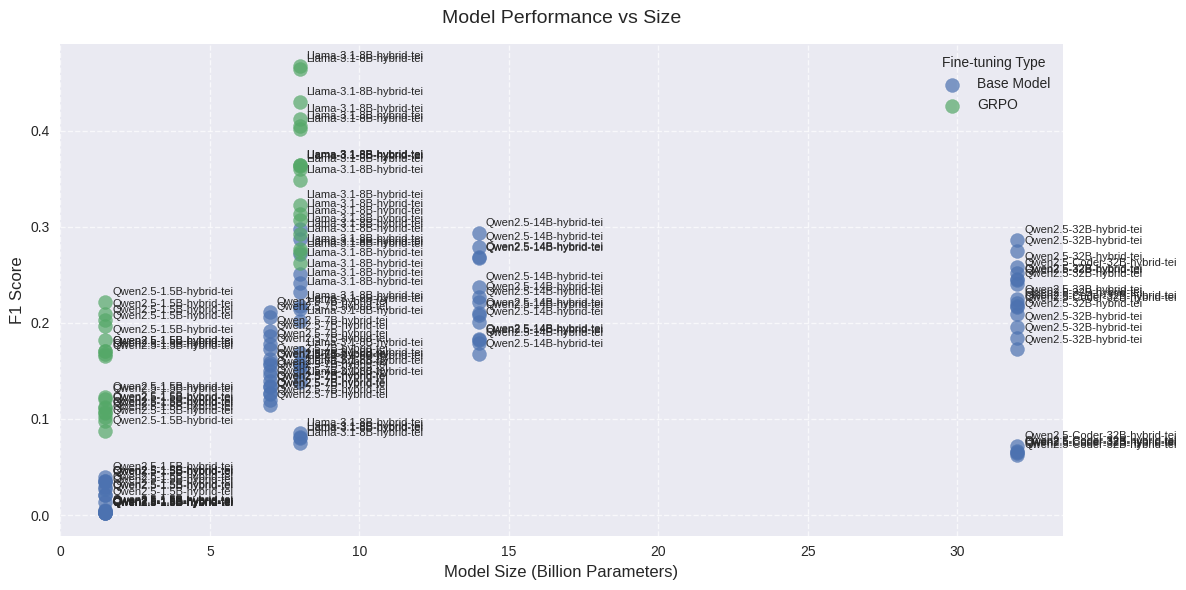

In [110]:
mask = df['params.dataset.path'] == 'bdsaglam/musique-mini'
scatter_plot(df[mask])

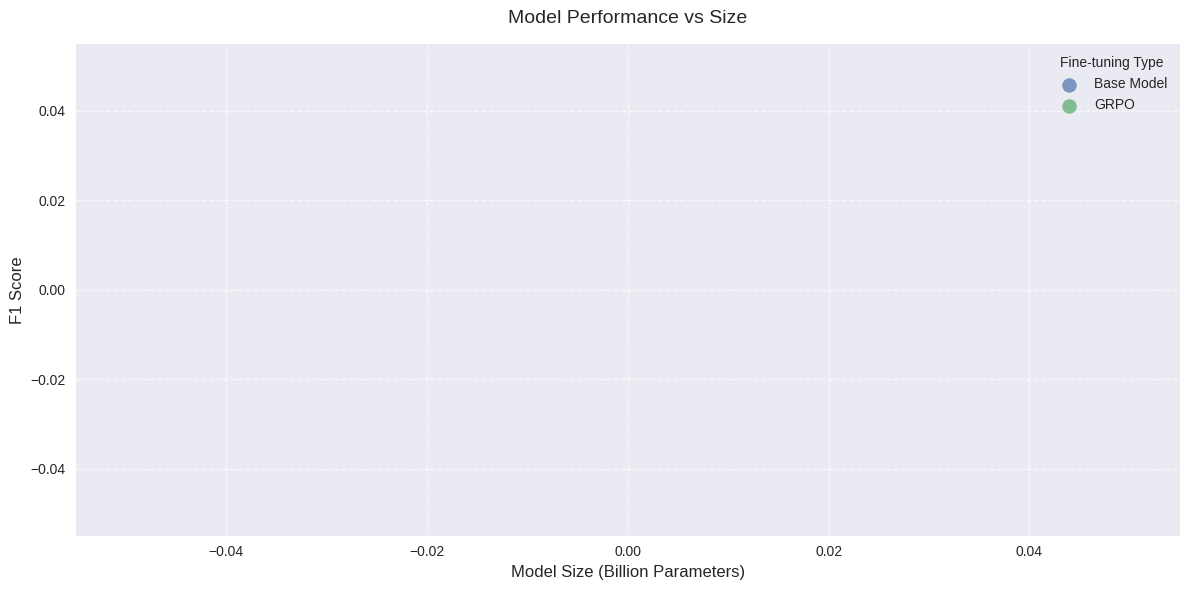

In [111]:
mask = df['params.dataset.path'] == 'bdsaglam/hotpotqa-distractor'
scatter_plot(df[mask])

In [112]:
def plot_model_size_vs_f1(df):
    """Create a publication-quality scatter plot comparing model size vs F1 score."""
    # Set style and figure size
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

    # Customize appearance
    ax.grid(True, linestyle="--", alpha=0.4, zorder=0)
    ax.set_xlabel("Model Size (Billion Parameters)", fontsize=12, fontweight="bold")
    ax.set_ylabel("F1 Score", fontsize=12, fontweight="bold")
    ax.set_title("Language Model Performance by Parameter Count", fontsize=14, pad=15, fontweight="bold")

    # Set x-axis to logarithmic scale
    ax.set_xscale('log')

    # Define colors and markers
    colors = {"None": "#2E86C1", "GRPO": "#E74C3C"}
    markers = {"None": "o", "GRPO": "^"}

    for fine_tuning in ["None", "GRPO"]:
        mask = df["params.fine_tuning"] == fine_tuning
        label = "Base Model" if fine_tuning == "None" else "GRPO Fine-tuned"

        # Plot points
        ax.scatter(
            df[mask]["params.model.size"],
            df[mask]["metrics.f1"],
            label=label,
            alpha=0.9,
            s=120,
            c=colors[fine_tuning],
            marker=markers[fine_tuning],
            edgecolor="white",
            linewidth=1,
            zorder=2,
        )

        # Add model name annotations
        for idx in df[mask].index:
            label = df.loc[idx, "params.model.base"].replace("Instruct", "").strip("-")
            plt.annotate(
                label,
                (df.loc[idx, "params.model.size"], df.loc[idx, "metrics.f1"]),
                xytext=(7, 7),
                textcoords="offset points",
                fontsize=9,
                alpha=0.8,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1),
            )

    # Customize legend
    ax.legend(title="Model Type", title_fontsize=10, fontsize=10, framealpha=0.9, edgecolor="none", loc="upper left")

    # Set axis limits with padding
    ax.set_xlim(left=1)  # Start at 1B parameters since using log scale
    ax.set_ylim(bottom=0)

    # Format axis ticks
    ax.tick_params(axis="both", which="major", labelsize=10)

    plt.tight_layout()
    plt.show()


In [113]:
def aggregate_best_models(df, by: list[str] = ["params.model.base", "params.fine_tuning"]):
    # Group by model base and fine tuning method
    grouped = df.groupby(by)

    # Get columns of interest
    columns = [
        "params.model.base",
        "params.model.size",
        "params.fine_tuning",
        "params.retriever.name",
        "params.retriever.top_k",
        "params.retriever.mode",
        "metrics.exact_match",
        "metrics.f1",
        "metrics.supporting.recall",
        "metrics.supporting.f1",
    ]

    # For each group, select the row with highest F1 score
    return (
        grouped.apply(lambda x: x.loc[x["metrics.f1"].idxmax()])[columns]
        .reset_index(drop=True)
        .sort_values(by="metrics.f1", ascending=False)
    )

/tmp/ipykernel_3899783/2309424635.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped.apply(lambda x: x.loc[x["metrics.f1"].idxmax()])[columns]


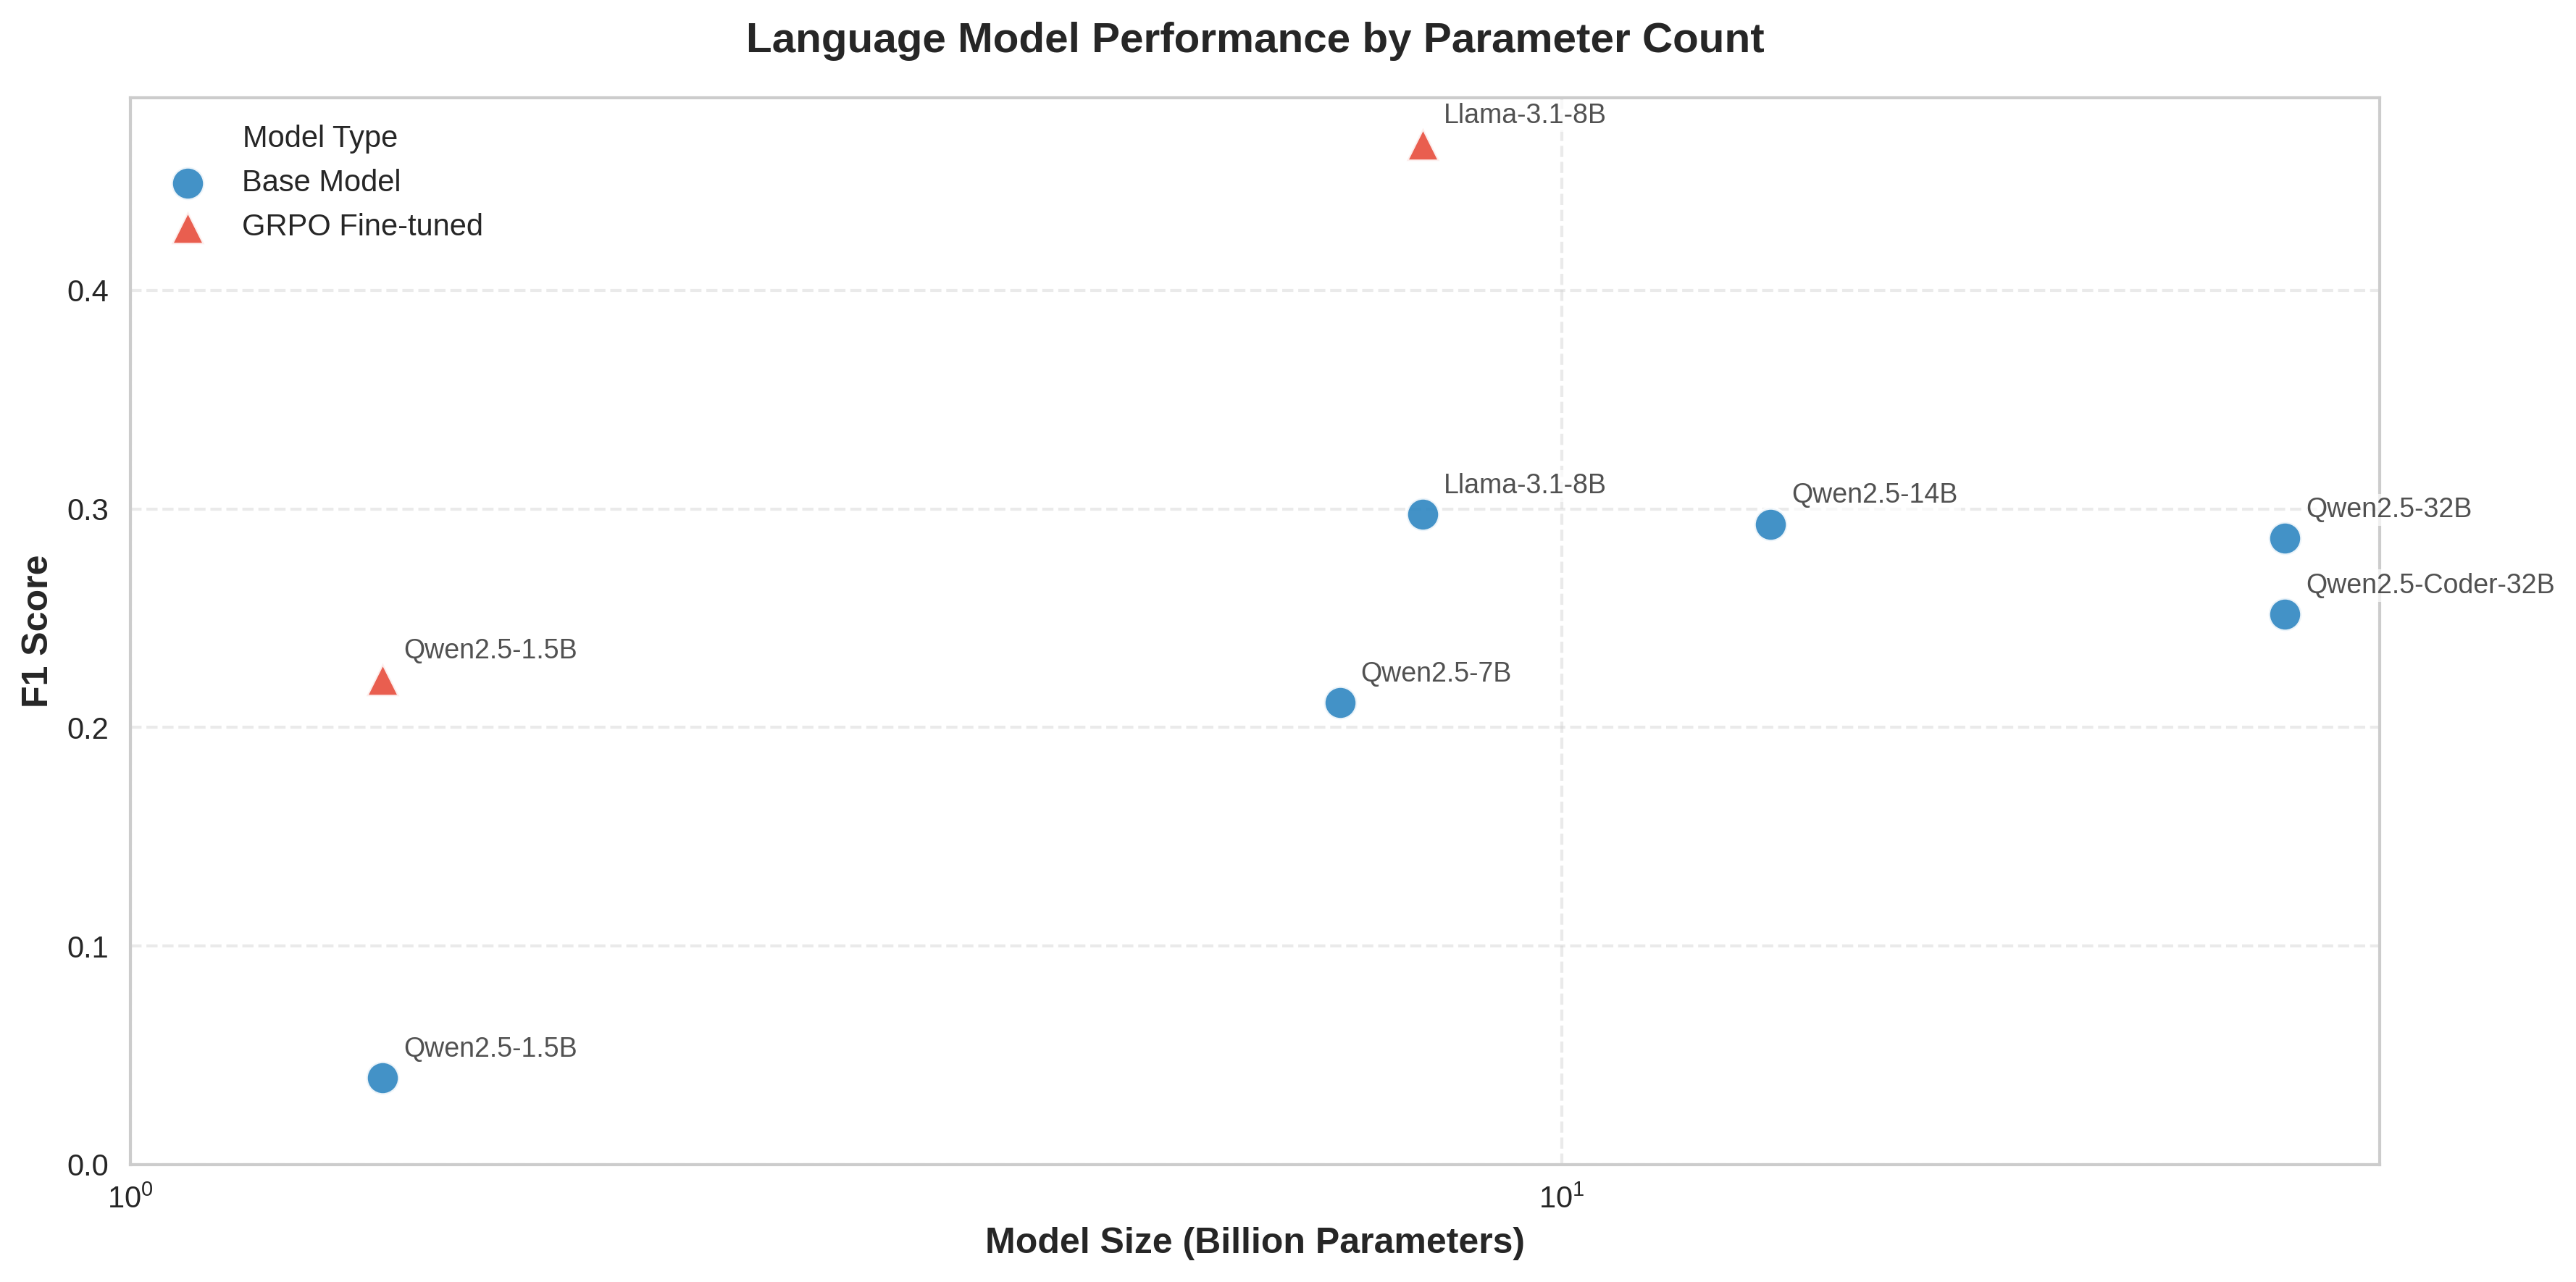

,params.model.base,params.model.size,params.fine_tuning,params.retriever.name,params.retriever.top_k,params.retriever.mode,metrics.exact_match,metrics.f1,metrics.supporting.recall,metrics.supporting.f1
0,Llama-3.1-8B,8.0,GRPO,hybrid-tei,1,all,0.396667,0.466928,0.709444,0.763865
1,Llama-3.1-8B,8.0,None,hybrid-tei,1,all,0.233333,0.297503,0.689444,0.750664
4,Qwen2.5-14B,14.0,None,hybrid-tei,1,all,0.210000,0.293042,0.653889,0.720381
5,Qwen2.5-32B,32.0,None,hybrid-tei,1,all,0.213333,0.286598,0.690278,0.742854
7,Qwen2.5-Coder-32B,32.0,None,hybrid-tei,2,all,0.190000,0.251886,0.679722,0.627623
2,Qwen2.5-1.5B,1.5,GRPO,hybrid-tei,1,all,0.163333,0.221953,0.545556,0.642222
6,Qwen2.5-7B,7.0,None,hybrid-tei,2,all,0.123333,0.211458,0.563611,0.544051
3,Qwen2.5-1.5B,1.5,None,hybrid-tei,3,all,0.026667,0.039673,0.507222,0.424266


In [114]:
mask = df['params.dataset.path'] == 'bdsaglam/musique-mini'
best_df = aggregate_best_models(df.loc[mask])
plot_model_size_vs_f1(best_df)
display(best_df)

/tmp/ipykernel_3899783/2309424635.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped.apply(lambda x: x.loc[x["metrics.f1"].idxmax()])[columns]


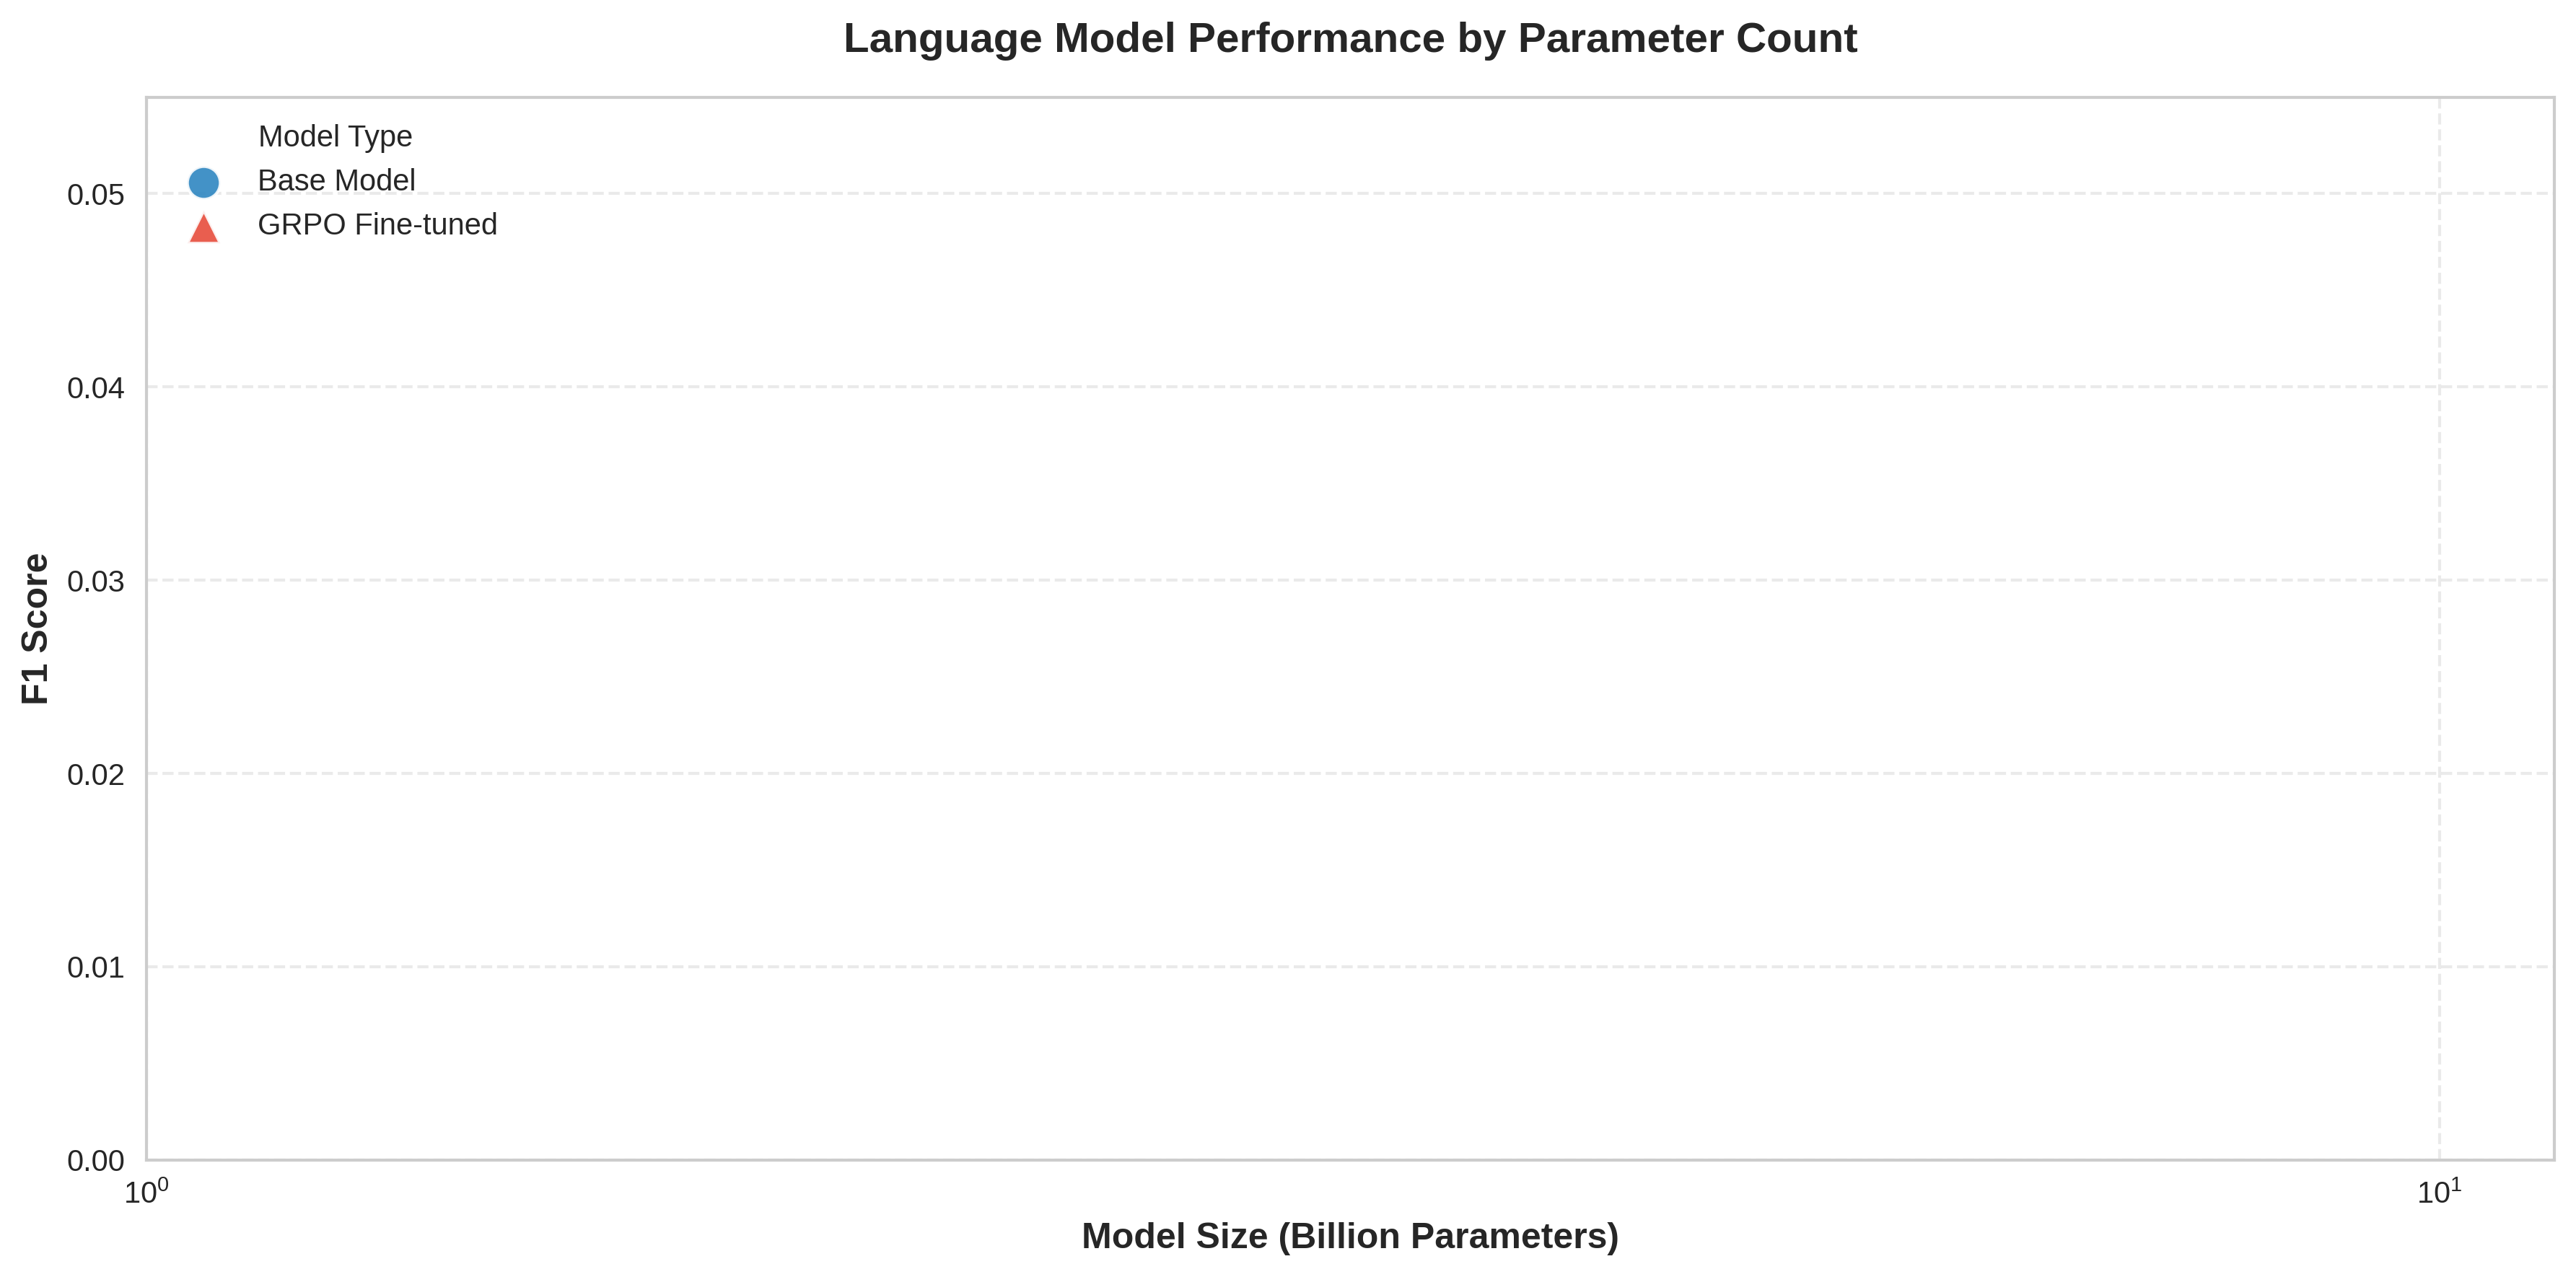

,params.model.base,params.model.size,params.fine_tuning,params.retriever.name,params.retriever.top_k,params.retriever.mode,metrics.exact_match,metrics.f1,metrics.supporting.recall,metrics.supporting.f1


In [115]:
mask = df['params.dataset.path'] == 'bdsaglam/hotpotqa-distractor'
best_df = aggregate_best_models(df.loc[mask])
plot_model_size_vs_f1(best_df)
display(best_df)

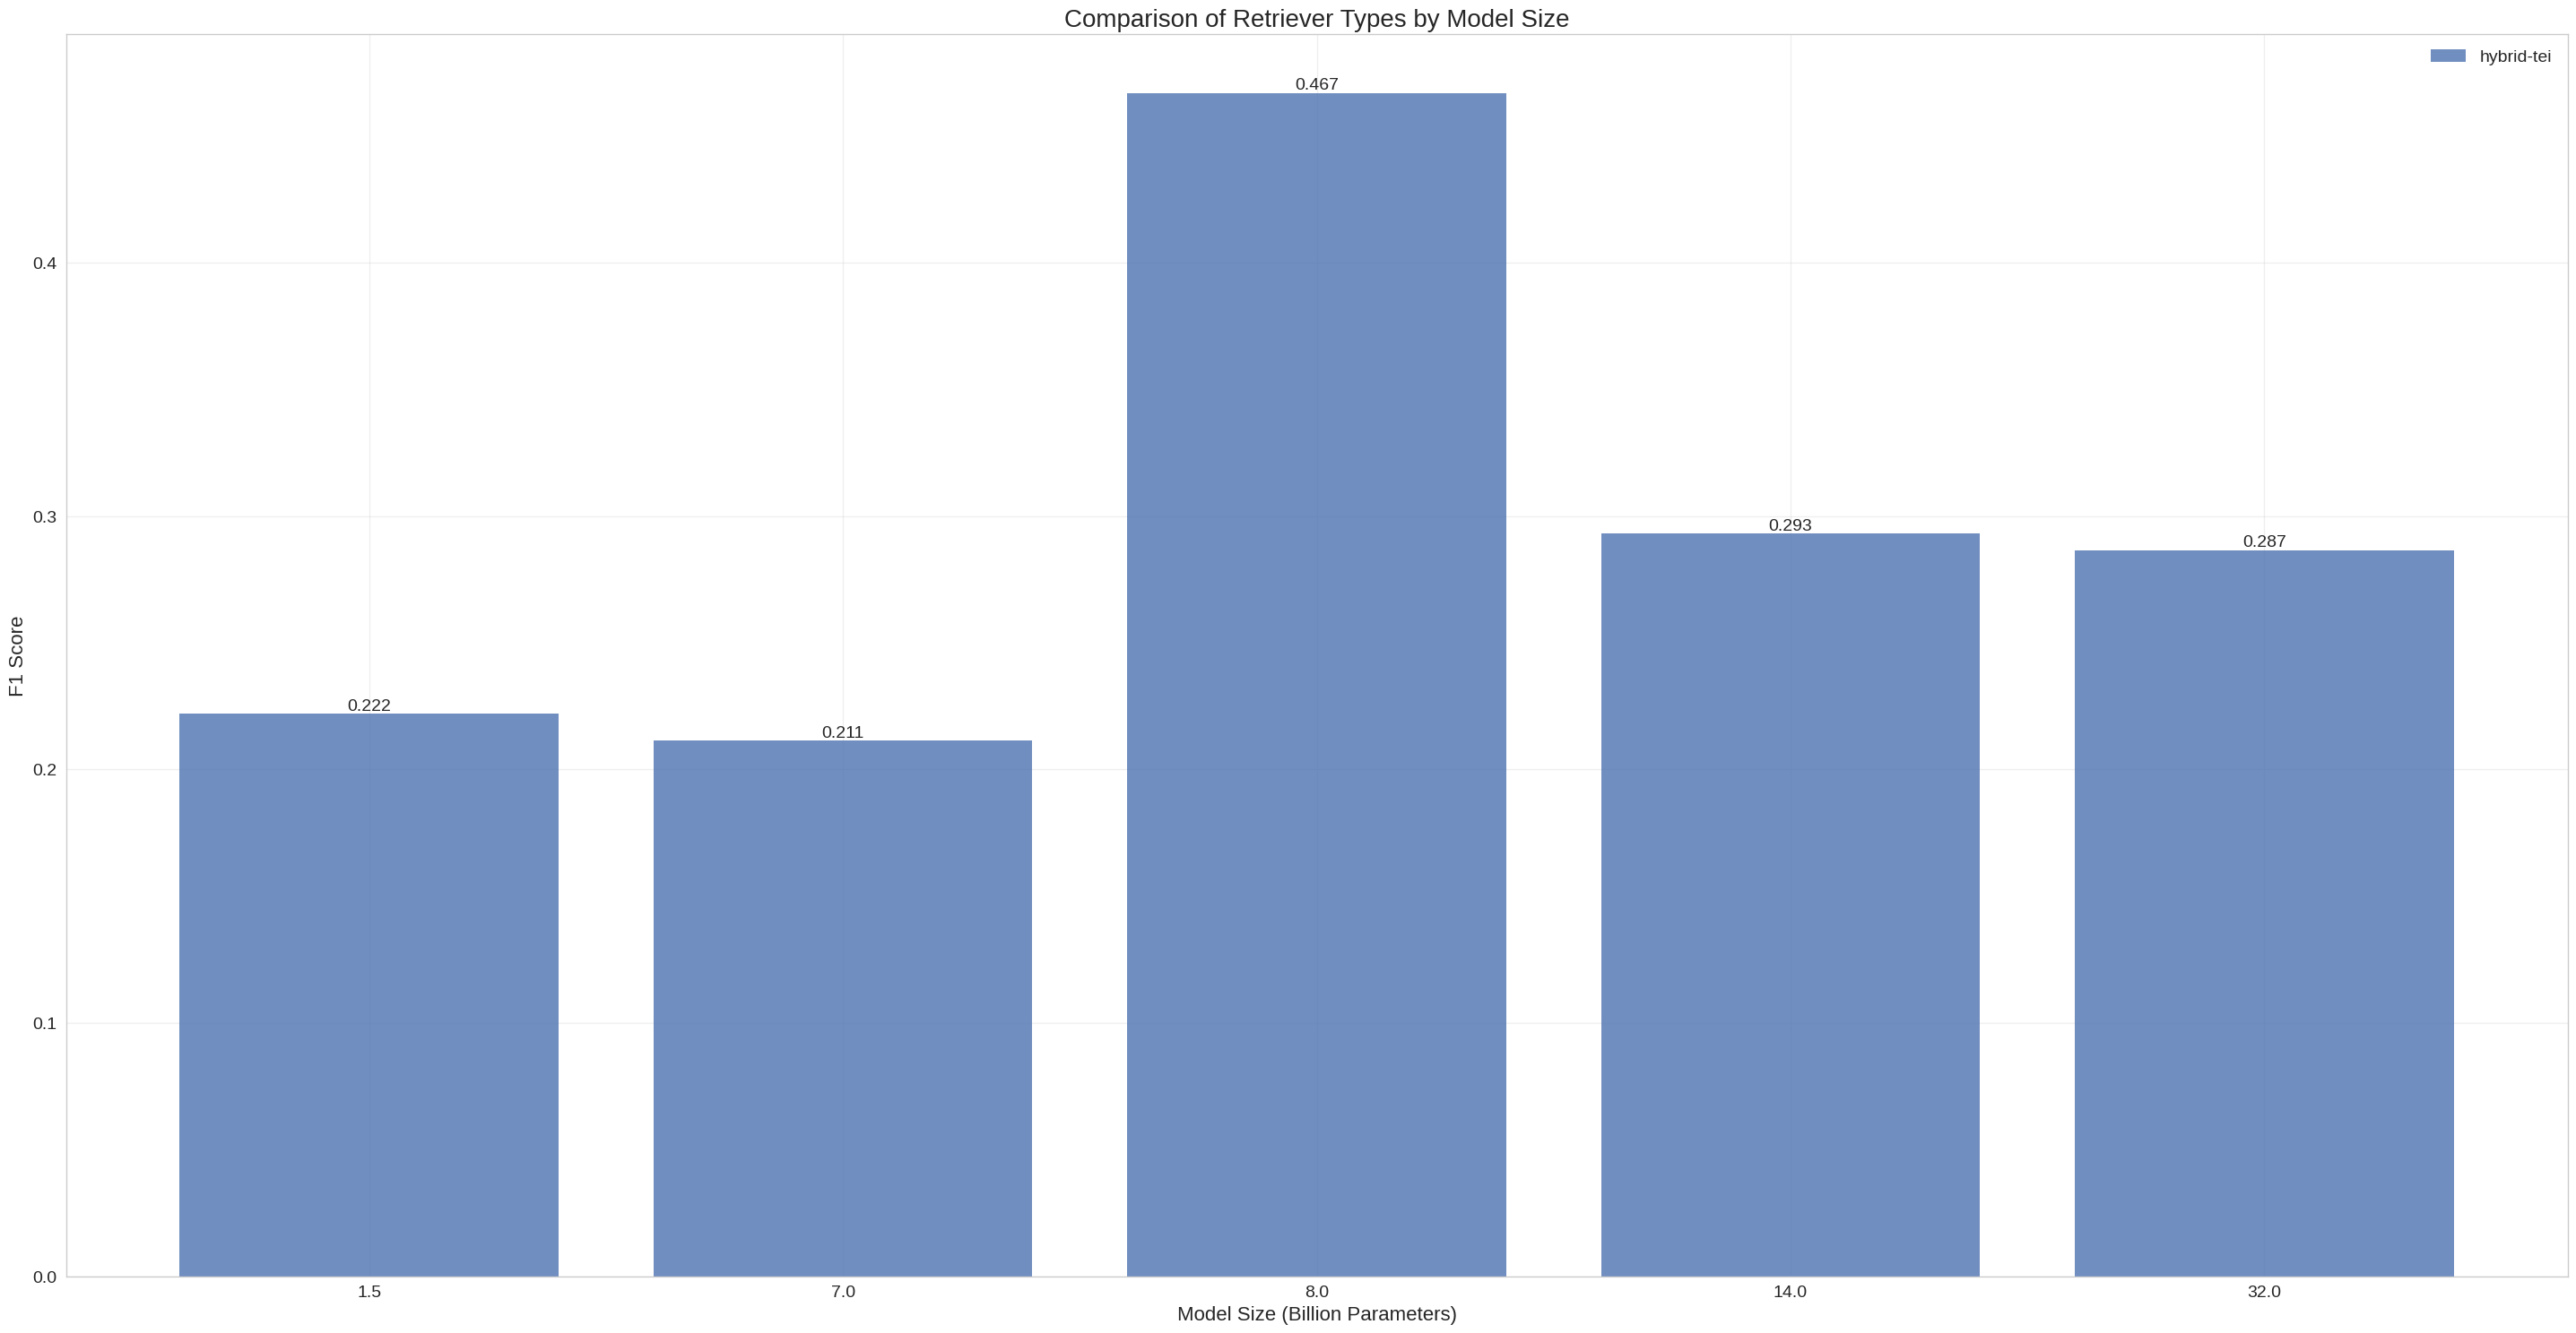

In [116]:
import numpy as np


def plot_retriever_comparison(df):
    plt.figure(figsize=(36, 18))

    # Group by model size and retriever type
    grouped = df.groupby(["params.model.size", "params.retriever.name"])

    # Get best results for each group
    retriever_df = grouped.agg({"metrics.f1": "max"}).reset_index()

    # Get unique model sizes and retriever types
    model_sizes = sorted(df["params.model.size"].unique())
    retriever_types = sorted(df["params.retriever.name"].unique())

    # Set up bar positions
    x = np.arange(len(model_sizes))
    width = 0.8 / len(retriever_types)

    # Create grouped bar plot
    for i, retriever in enumerate(retriever_types):
        data = retriever_df[retriever_df["params.retriever.name"] == retriever]
        heights = [
            data[data["params.model.size"] == size]["metrics.f1"].values[0]
            if len(data[data["params.model.size"] == size]) > 0
            else 0
            for size in model_sizes
        ]

        pos = x + i * width - (len(retriever_types) - 1) * width / 2
        bars = plt.bar(pos, heights, width, label=retriever, alpha=0.8)

        # Add value labels
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.3f}", ha="center", va="bottom", fontsize=14)

    # Customize plot
    plt.title("Comparison of Retriever Types by Model Size", fontsize=20)
    plt.xlabel("Model Size (Billion Parameters)", fontsize=16)
    plt.ylabel("F1 Score", fontsize=16)
    plt.xticks(x, model_sizes, fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.show()

mask = df['params.dataset.path'] == 'bdsaglam/musique-mini'
plot_retriever_comparison(df.loc[mask])


In [117]:
import numpy as np


def plot_retriever_mode_comparison(df):
    plt.figure(figsize=(36, 18))

    # Group by model size and retriever type
    grouped = df.groupby(["params.model.size", "params.retriever.mode"])

    # Get best results for each group
    retriever_df = grouped.agg({"metrics.f1": "max"}).reset_index()

    # Get unique model sizes and retriever types
    model_sizes = sorted(df["params.model.size"].unique())
    retriever_types = sorted(df["params.retriever.mode"].unique())

    # Set up bar positions
    x = np.arange(len(model_sizes))
    width = 0.8 / len(retriever_types)

    # Create grouped bar plot
    for i, retriever in enumerate(retriever_types):
        data = retriever_df[retriever_df["params.retriever.mode"] == retriever]
        heights = [
            data[data["params.model.size"] == size]["metrics.f1"].values[0]
            if len(data[data["params.model.size"] == size]) > 0
            else 0
            for size in model_sizes
        ]

        pos = x + i * width - (len(retriever_types) - 1) * width / 2
        bars = plt.bar(pos, heights, width, label=retriever, alpha=0.8)

        # Add value labels
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.3f}", ha="center", va="bottom", fontsize=14)

    # Customize plot
    plt.title("Comparison of Retriever Modes by Model Size", fontsize=20)
    plt.xlabel("Model Size (Billion Parameters)", fontsize=16)
    plt.ylabel("F1 Score", fontsize=16)
    plt.xticks(x, model_sizes, fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.show()

mask = (df['params.dataset.path'] == 'bdsaglam/musique-mini') & (df['params.retriever.name'] == 'hybrid')
plot_retriever_mode_comparison(df.loc[mask])


ZeroDivisionError: float division by zero

<Figure size 3600x1800 with 0 Axes>

In [286]:
mask = (df['params.retriever.mode'] == 'new') & (df['params.dataset.path'] == 'bdsaglam/musique-mini')
_df_1 = df.loc[mask, target_params + ['metrics.f1']].sort_values(by='metrics.f1', ascending=False)
_df_1

,params.dataset.path,params.model.name,params.model.size,params.model.few_shot_prob,params.fine_tuning,params.retriever.name,params.retriever.top_k,params.retriever.mode,metrics.f1
2,bdsaglam/musique-mini,Llama-3.1-8B-ragent,8.0,0,GRPO,hybrid,1,new,0.437382
1,bdsaglam/musique-mini,Llama-3.1-8B-ragent-2,8.0,1,GRPO,hybrid,1,new,0.388319
5,bdsaglam/musique-mini,Llama-3.1-8B-ragent-2,8.0,0,GRPO,hybrid,1,new,0.363662
7,bdsaglam/musique-mini,Llama-3.1-8B-ragent,8.0,1,GRPO,hybrid,1,new,0.064810


In [287]:
mask = (df['params.retriever.mode'] == 'all') & (df['params.dataset.path'] == 'bdsaglam/musique-mini')
_df_2 = df.loc[mask, target_params + ['metrics.f1']].sort_values(by='metrics.f1', ascending=False)
_df_2

,params.dataset.path,params.model.name,params.model.size,params.model.few_shot_prob,params.fine_tuning,params.retriever.name,params.retriever.top_k,params.retriever.mode,metrics.f1
0,bdsaglam/musique-mini,Llama-3.1-8B-ragent,8.0,0,GRPO,hybrid,1,all,0.449677
3,bdsaglam/musique-mini,Llama-3.1-8B-ragent,8.0,1,GRPO,hybrid,1,all,0.435698
4,bdsaglam/musique-mini,Llama-3.1-8B-ragent-2,8.0,0,GRPO,hybrid,1,all,0.317435
6,bdsaglam/musique-mini,Llama-3.1-8B-ragent-2,8.0,1,GRPO,hybrid,1,all,0.236873
